In [129]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron

iris = load_iris(as_frame=True)
X = iris.data[['petal length (cm)',"petal width (cm)"]].values
y = (iris.target == 0)  

per_clf = Perceptron(random_state=42)
per_clf.fit(X,y)

X_new = [[2,0.5],[3,1]]
y_pred = per_clf.predict(X_new)
y_pred

array([ True, False])

In [130]:
# from sklearn.datasets import fetch_california_housing
# from sklearn.metrics import root_mean_squared_error
# from sklearn.model_selection import train_test_split
# from sklearn.neural_network import MLPRegressor
# from sklearn.pipeline import make_pipeline
# from sklearn.preprocessing import StandardScaler

# housing = fetch_california_housing()
# X_train_full,X_test,y_train_full,y_test = train_test_split(housing.data,housing.target,random_state=42)
# X_train,X_valid,y_train,y_valid = train_test_split(X_train_full,y_train_full,random_state=42)

# mlp_reg = MLPRegressor(hidden_layer_sizes=[50,50,50],random_state=42)
# pipeline = make_pipeline(StandardScaler(),mlp_reg)
# pipeline.fit(X_train,y_train)
# y_pred = pipeline.predict(X_valid)
# rmse = root_mean_squared_error(y_valid,y_pred)
# rmse

In [131]:
import tensorflow as tf
import keras
fashion_mnist = keras.datasets.fashion_mnist.load_data()
(X_train_full,Y_train_full) , (X_test,Y_test) = fashion_mnist
X_train,Y_train = X_train_full[:-5000],Y_train_full[:-5000]
X_valid,Y_valid = X_train_full[-5000:],Y_train_full[-5000:]

In [132]:
X_train.shape

(55000, 28, 28)

In [133]:
X_train.dtype

dtype('uint8')

In [134]:
X_train,X_valid,X_test = X_train / 255 , X_valid / 255 , X_test / 255

In [135]:
class_names = ['T-shirt / top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle-Boot']

In [136]:
class_names[Y_train[16]]

'Trouser'

In [137]:
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape = [28,28]))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(300,activation = 'relu'))
model.add(tf.keras.layers.Dense(100,activation = 'relu'))
model.add(tf.keras.layers.Dense(10,activation = 'softmax'))

In [138]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [139]:
# model = tf.keras.Sequential([
#     tf.keras.layers.Flatten(input_shape = [28,28]),
#     tf.keras.layers.Dense(300,activation='relu'),
#     tf.keras.layers.Dense(100,activation='relu'),
#     tf.keras.layers.Dense(10,activation = 'softmax')
# ])

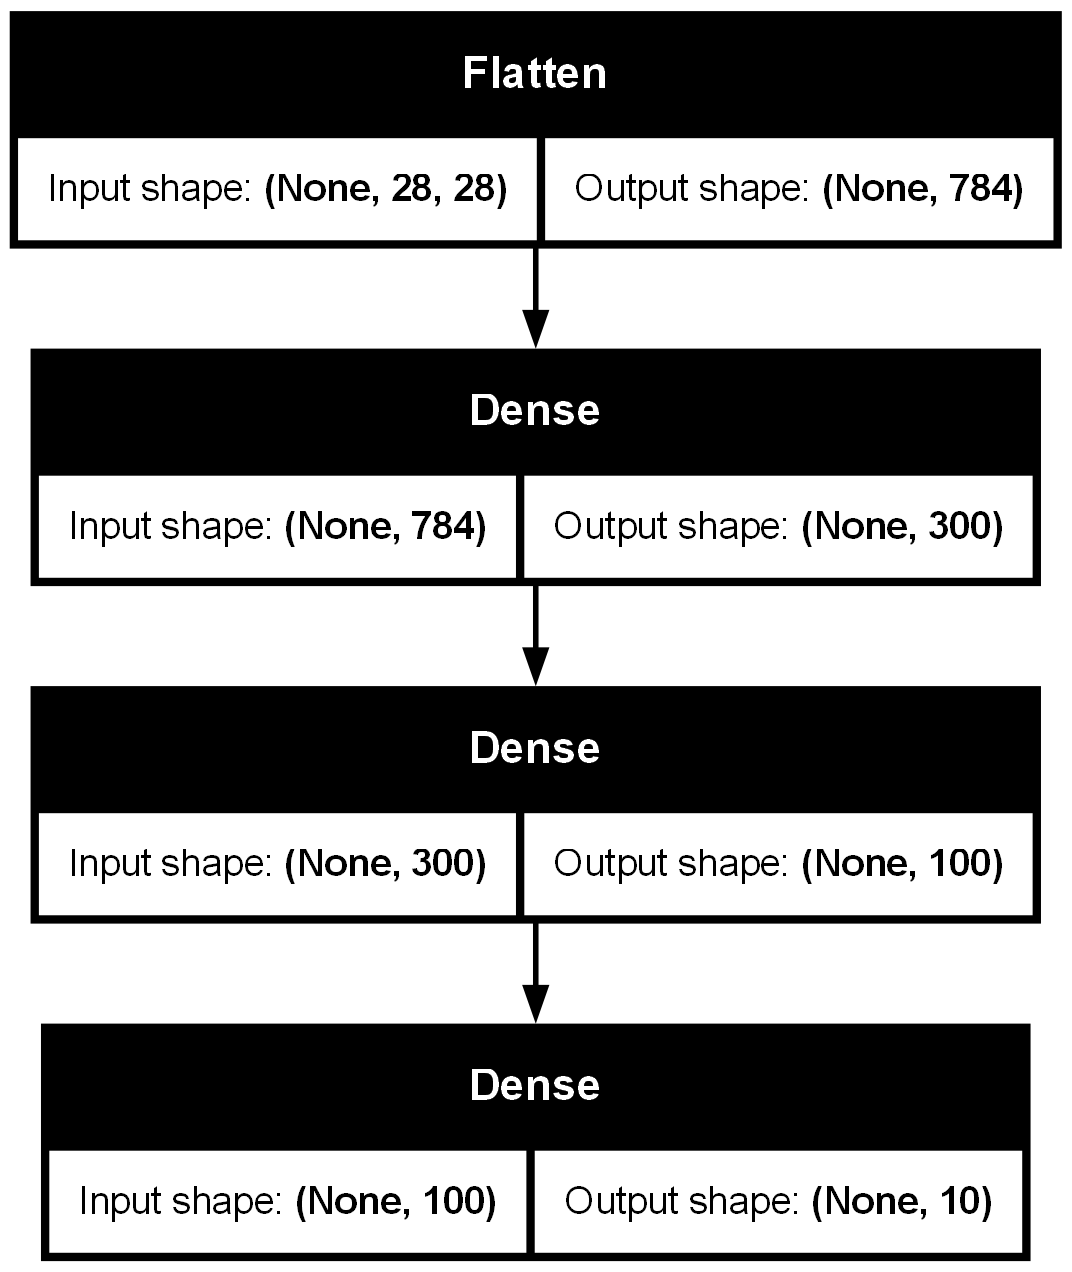

In [140]:
keras.utils.plot_model(model,show_shapes=True)

In [141]:
model.layers

[<Flatten name=flatten_1, built=True>,
 <Dense name=dense_71, built=True>,
 <Dense name=dense_72, built=True>,
 <Dense name=dense_73, built=True>]

In [142]:
hidden1 = model.layers[1]
hidden1.name

weights,biases = hidden1.get_weights()
weights

array([[-0.00164953, -0.0719072 ,  0.04857701, ..., -0.02769078,
        -0.0599189 ,  0.00247961],
       [-0.04634333,  0.04471254, -0.04894928, ..., -0.0058898 ,
         0.05407448, -0.02281516],
       [ 0.06186101, -0.01758992,  0.03063904, ...,  0.04633147,
        -0.05464988,  0.01983119],
       ...,
       [-0.04200636, -0.04248388, -0.06495162, ...,  0.00659935,
        -0.00072179,  0.04746314],
       [ 0.00559787,  0.05550426,  0.01869896, ...,  0.06633037,
         0.06619303, -0.00065332],
       [ 0.00707252, -0.01564443,  0.06175989, ..., -0.0343978 ,
        -0.04297775,  0.07235458]], dtype=float32)

In [143]:
weights.shape

(784, 300)

In [144]:
biases.shape

(300,)

In [145]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [146]:
model.compile(loss = 'sparse_categorical_crossentropy',
              optimizer = tf.keras.optimizers.SGD(learning_rate=0.002),
              metrics = ['accuracy'])

In [147]:
Y_hot_train = tf.keras.utils.to_categorical(Y_train) # Used for one hot encoding

In [148]:
np.argmax(Y_hot_train,axis = 1) # for converting one-hot encoded labels into simple implementations

array([9, 0, 0, ..., 9, 0, 2], dtype=int64)

In [149]:
history = model.fit(X_train,Y_train,epochs = 30,validation_data = (X_valid,Y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5460 - loss: 1.5152 - val_accuracy: 0.7698 - val_loss: 0.7320
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7691 - loss: 0.7085 - val_accuracy: 0.8040 - val_loss: 0.6005
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8014 - loss: 0.6006 - val_accuracy: 0.8208 - val_loss: 0.5446
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8178 - loss: 0.5491 - val_accuracy: 0.8278 - val_loss: 0.5119
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8275 - loss: 0.5169 - val_accuracy: 0.8326 - val_loss: 0.4894
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8355 - loss: 0.4939 - val_accuracy: 0.8354 - val_loss: 0.4725
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8410 - loss: 0.4764 - val_accuracy: 0.8384 - val_loss: 0.4596
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8444 - loss: 0.4625 - 

In [150]:
history.params

{'verbose': 'auto', 'epochs': 30, 'steps': 1719}

In [151]:
history.epoch

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29]

In [152]:
history.history

{'accuracy': [0.6640909314155579,
  0.7791091203689575,
  0.8063636422157288,
  0.8203091025352478,
  0.8292545676231384,
  0.8356545567512512,
  0.8406727313995361,
  0.8446363806724548,
  0.8474909067153931,
  0.850418210029602,
  0.8530181646347046,
  0.8549454808235168,
  0.8571636080741882,
  0.8587636351585388,
  0.8604182004928589,
  0.8621454834938049,
  0.8636363744735718,
  0.8659090995788574,
  0.8670363426208496,
  0.8681636452674866,
  0.8691090941429138,
  0.8702181577682495,
  0.8712727427482605,
  0.8723999857902527,
  0.8734727501869202,
  0.8744727373123169,
  0.8751817941665649,
  0.8760727047920227,
  0.8771272897720337,
  0.8781090974807739],
 'loss': [1.1286842823028564,
  0.6723109483718872,
  0.5835287570953369,
  0.5378745198249817,
  0.5083478093147278,
  0.4869728088378906,
  0.4705069363117218,
  0.45735156536102295,
  0.44648149609565735,
  0.4372154176235199,
  0.4291762411594391,
  0.42205533385276794,
  0.41561615467071533,
  0.40975525975227356,
  0.404

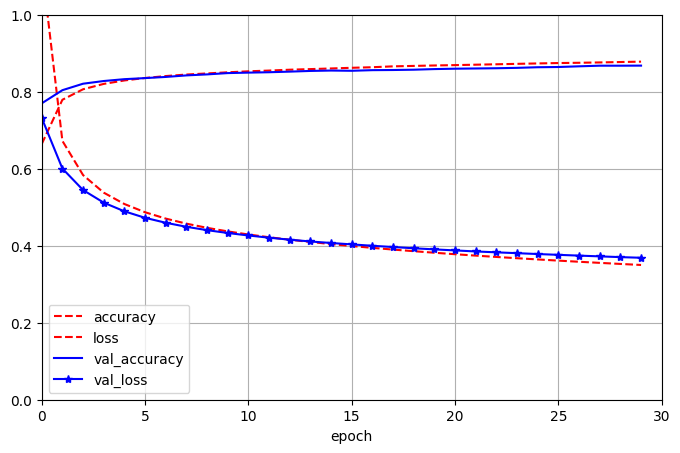

In [153]:
import matplotlib.pyplot as plt
import pandas as pd

pd.DataFrame(history.history).plot(
    figsize=(8,5),xlim = [0,30],ylim = [0,1],grid = True,xlabel='epoch',style = ['r--','r--','b-','b-*']
)
plt.show()

In [154]:
model.evaluate(X_test,Y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1000us/step - accuracy: 0.8640 - loss: 0.3925


[0.39731213450431824, 0.8593999743461609]

In [155]:
X_new = X_test[:3]

In [156]:
y_proba = model.predict(X_new)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


In [157]:
y_proba.round(2)

array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.16, 0.  , 0.15, 0.  , 0.68],
       [0.  , 0.  , 0.98, 0.  , 0.01, 0.  , 0.01, 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]],
      dtype=float32)

In [158]:
y_pred = y_proba.argmax(axis = 1)
y_pred

array([9, 2, 1], dtype=int64)

In [159]:
import numpy as np
np.array(class_names)[y_pred]

array(['Ankle-Boot', 'Pullover', 'Trouser'], dtype='<U13')

In [160]:
tf.random.set_seed(42)

In [161]:
norm_layer = keras.layers.Normalization(input_shape = X_train.shape[1:])
model = keras.Sequential([
    norm_layer,
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(1)
])

optimizer = keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss = 'mse',optimizer = optimizer, metrics = ['RootMeanSquaredError'])
norm_layer.adapt(X_train)

history = model.fit(X_train,Y_train,epochs = 20,validation_data=(X_valid,Y_valid))
mse_test,rmse_test = model.evaluate(X_test,Y_test)
X_new = X_test[:3]
y_pred = model.predict(X_new)

c:\Users\jitik\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - RootMeanSquaredError: 3.0763 - loss: 9.5589 - val_RootMeanSquaredError: 2.9015 - val_loss: 8.4188
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - RootMeanSquaredError: 2.8831 - loss: 8.3121 - val_RootMeanSquaredError: 2.9001 - val_loss: 8.4107
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - RootMeanSquaredError: 2.8787 - loss: 8.2868 - val_RootMeanSquaredError: 2.9000 - val_loss: 8.4101
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - RootMeanSquaredError: 2.8772 - loss: 8.2784 - val_RootMeanSquaredError: 2.8979 - val_loss: 8.3977
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - RootMeanSquaredError: 2.8762 - loss: 8.2727 - val_RootMeanSquaredError: 2.8970 - val_loss: 8.3924
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - RootMeanSquaredError: 2.8755 - loss: 8.2688 - val_RootMeanSquaredError: 2.8959 - val_loss: 8.3864
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - RootMeanSquaredError

In [162]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_33                │ (None, 28, 28)         │            57 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 28, 50)         │         1,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 28, 50)         │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 28, 50)         │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 28, 1)          │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,862 (77.59 KB)

 Trainable params: 6,601 (25.79 KB)

 Non-trainable params: 57 (232.00 B)

 Optimizer params: 13,204 (51.58 KB)

In [163]:
model.layers

[<Normalization name=normalization_33, built=True>,
 <Dense name=dense_74, built=True>,
 <Dense name=dense_75, built=True>,
 <Dense name=dense_76, built=True>,
 <Dense name=dense_77, built=True>]

In [164]:
X_train.shape

(55000, 28, 28)

In [165]:
_ = X_train

In [166]:
normalization_layer = keras.layers.Normalization()
hidden_layer_1 = keras.layers.Dense(30,activation='relu')
hidden_layer_2 = keras.layers.Dense(30,activation='relu')
concat_layer = keras.layers.Concatenate()
output_layer = keras.layers.Dense(1)

input_ = keras.layers.Input(shape = _.shape[1:])
normalized = normalization_layer(input_)
hidden1 = hidden_layer_1(normalized)
hidden2 = hidden_layer_2(hidden1)
concat = concat_layer([hidden2,normalized])
output_ = output_layer(concat)

model = keras.Model(inputs = [input_],outputs = [output_])
# Next we complie the model , adapt the normalization layer and then fit and evaluate and then predict                                         

In [167]:
input_wide = tf.keras.layers.Input(shape=[5])  # features 0 to 4
input_deep = tf.keras.layers.Input(shape=[6])  # features 2 to 7
norm_layer_wide = tf.keras.layers.Normalization()
norm_layer_deep = tf.keras.layers.Normalization()
norm_wide = norm_layer_wide(input_wide)
norm_deep = norm_layer_deep(input_deep)
hidden1 = tf.keras.layers.Dense(30, activation="relu")(norm_deep)
hidden2 = tf.keras.layers.Dense(30, activation="relu")(hidden1)
concat = tf.keras.layers.concatenate([norm_wide, hidden2])
output = tf.keras.layers.Dense(1)(concat)
model = tf.keras.Model(inputs=[input_wide, input_deep], outputs=[output])

In [168]:
# optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
# model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])

# X_train_wide, X_train_deep = X_train[:, :5], X_train[:, 2:]
# X_valid_wide, X_valid_deep = X_valid[:, :5], X_valid[:, 2:]
# X_test_wide, X_test_deep = X_test[:, :5], X_test[:, 2:]
# X_new_wide, X_new_deep = X_test_wide[:3], X_test_deep[:3]

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])

X_train_wide, X_train_deep = X_train[:, :5], X_train[:, 2:]
X_valid_wide, X_valid_deep = X_valid[:, :5], X_valid[:, 2:]
X_test_wide, X_test_deep = X_test[:, :5], X_test[:, 2:]
X_new_wide, X_new_deep = X_test_wide[:3], X_test_deep[:3]

In [169]:
print("X_train_wide shape:", X_train_wide.shape)
print("X_train_deep shape:", X_train_deep.shape)
print("Sample of X_train_wide data:", X_train_wide[0])

X_train_wide shape: (55000, 5, 28)
X_train_deep shape: (55000, 26, 28)
Sample of X_train_wide data: [[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.  

In [170]:
norm_layer_wide.adapt(X_train_wide)
norm_layer_deep.adapt(X_train_deep)
history = model.fit((X_train_wide, X_train_deep), Y_train, epochs=20,
                    validation_data=((X_valid_wide, X_valid_deep), Y_valid))
mse_test = model.evaluate((X_test_wide, X_test_deep), Y_test)
y_pred = model.predict((X_new_wide, X_new_deep))

ValueError: The shape of the target variable and the shape of the target value in `variable.assign(value)` must match. variable.shape=(5,), Received: value.shape=(5, 28). Target variable: <Variable path=normalization_35/mean, shape=(5,), dtype=float32, value=[0. 0. 0. 0. 0.]>

In [ ]:
input_wide = keras.layers.Input(shape = [5])
input_deep = keras.layers.Input(shape = [6])

norm_layer_wide = keras.layers.Normalization()
norm_layer_deep = keras.layers.Normalization()

norm_wide = norm_layer_wide(input_wide)
norm_deep = norm_layer_deep(input_deep)

hidden1 = keras.layers.Dense(30,activation='relu')(norm_deep)
hidden2 = keras.layers.Dense(30,activation='relu')(hidden1)
# concat = keras.layers.concatenate([norm_wide,hidden2]) # Can write below line as this too
concat = keras.layers.Concatenate()([norm_wide,hidden2])
output = keras.layers.Dense(1)(concat)

model = keras.Model(inputs = [input_wide,input_deep], outputs = [output])

In [ ]:
# optimizers = keras.optimizers.Adam(learning_rate=0.01)
# model.compile(optimizer=optimizers,loss = keras.losses.mean_squared_error,metrics = ['RootMeanSquaredError'])
# X_train_wide,X_train_deep = X_train[:,:5] , X_train[:,2:]
# X_valid_wide,X_valid_deep = X_valid[:,:5], X_valid[:,:5]
# X_test_wide,X_test_deep = X_test[:,:5], X_test[:,2:]
# X_new_wide, X_new_deep = X_test_wide[:3], X_test_deep[:3]

# norm_layer_wide.adapt(X_train_wide)
# norm_layer_deep.adapt(X_train_deep)

# history = model.fit({'input_wide':X_train_wide,'input_deep':X_train_deep},Y_train,epochs = 20,validation_data=((X_valid_wide,X_valid_deep),Y_valid))
# mse_test = model.evaluate((X_test_wide,X_test_deep),Y_test)
# y_pred = model.predict((X_new_wide,X_new_deep))

# history = model.fit()

In [ ]:
X_train = _

In [ ]:
X_train.shape

(55000, 28, 28)

In [178]:
class WideAndDeepModel(keras.Model):
    def __init__(self,units = 30, activation = 'relu', **kwargs):
        super().__init__(**kwargs) # Necceasy for keyword arguments like names
        self.norm_layer_wide = keras.layers.Normalization()
        self.norm_layer_deep = keras.layers.Normalization()
        self.hidden1 = keras.layers.Dense(units,activation=activation)
        self.hidden2 = keras.layers.Dense(units,activation=activation)
        self.concat_layer = keras.layers.Concatenate()
        self.main_output = keras.layers.Dense(1)
        self.aux_output = keras.layers.Dense(1)
    
    def call(self,inputs):
        input_wide,input_deep = inputs
        norm_wide = self.norm_layer_wide(input_wide)
        norm_deep = self.norm_layer_deep(input_deep)
        hidden1 = self.hidden1(norm_deep)
        hidden2 = self.hidden2(hidden1)
        concat = self.concat_layer([hidden2,norm_wide])
        output = self.main_output(concat)
        aux_output = self.aux_output(hidden2)
        return output,aux_output
        

In [192]:
model = WideAndDeepModel(units = 40,activation='relu',name = 'my_cool_model')
model.compile()

In [193]:
model.save('my_keras_model.keras')

c:\Users\jitik\anaconda3\Lib\site-packages\keras\src\saving\saving_api.py:107: UserWarning: You are saving a model that has not yet been built. It might not contain any weights yet. Consider building the model first by calling it on some data.
  return saving_lib.save_model(model, filepath)


In [197]:
norm_layer = keras.layers.Normalization(input_shape = X_train.shape[1:])
model = keras.Sequential([
    norm_layer,
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(1)
])

optimizer = keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss = 'mse',optimizer = optimizer, metrics = ['RootMeanSquaredError'])
norm_layer.adapt(X_train)

# mse_test,rmse_test = model.evaluate(X_test,Y_test)
# X_new = X_test[:3]
# y_pred = model.predict(X_new)

c:\Users\jitik\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [198]:
checkpoint_cb = keras.callbacks.ModelCheckpoint("my_checkpoint.weights.h5",save_best_only=True,save_weights_only=True)
history = model.fit(X_train,Y_train,epochs = 20,validation_data=(X_valid,Y_valid),callbacks=[checkpoint_cb])

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - RootMeanSquaredError: 3.0089 - loss: 9.0925 - val_RootMeanSquaredError: 2.9014 - val_loss: 8.4179
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - RootMeanSquaredError: 2.8832 - loss: 8.3131 - val_RootMeanSquaredError: 2.9005 - val_loss: 8.4129
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - RootMeanSquaredError: 2.8787 - loss: 8.2871 - val_RootMeanSquaredError: 2.8997 - val_loss: 8.4083
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - RootMeanSquaredError: 2.8767 - loss: 8.2757 - val_RootMeanSquaredError: 2.8977 - val_loss: 8.3967
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - RootMeanSquaredError: 2.8756 - loss: 8.2691 - val_RootMeanSquaredError: 2.8958 - val_loss: 8.3855
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - RootMeanSquaredError: 2.8748 - loss: 8.2644 - val_RootMeanSquaredError: 2.8939 - val_loss: 8.3744
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - RootMeanSquaredError

In [201]:
early_cb = keras.callbacks.EarlyStopping(patience=1,verbose=1)
history = model.fit(X_train,Y_train,epochs = 20,validation_data=(X_valid,Y_valid),callbacks=[early_cb])

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - RootMeanSquaredError: 2.8713 - loss: 8.2441 - val_RootMeanSquaredError: 2.8933 - val_loss: 8.3709
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - RootMeanSquaredError: 2.8711 - loss: 8.2432 - val_RootMeanSquaredError: 2.8933 - val_loss: 8.3709
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - RootMeanSquaredError: 2.8711 - loss: 8.2430 - val_RootMeanSquaredError: 2.8933 - val_loss: 8.3711
Epoch 3: early stopping


In [202]:
history = model.fit(X_train,Y_train,epochs = 20,validation_data=(X_valid,Y_valid),callbacks=[early_cb,checkpoint_cb])

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - RootMeanSquaredError: 2.8711 - loss: 8.2431 - val_RootMeanSquaredError: 2.8933 - val_loss: 8.3711
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - RootMeanSquaredError: 2.8710 - loss: 8.2429 - val_RootMeanSquaredError: 2.8933 - val_loss: 8.3712
Epoch 2: early stopping


In [203]:
class PrintVaLTrainingRatioCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        # return super().on_epoch_end(epoch, logs)
        ratio = logs['val_loss'] / logs['loss']
        print(f'epoch = {epoch} , val/train = {ratio:.2f}')

In [239]:
from pathlib import Path
from time import strftime
# Created directories based on time
def get_run_logdir(root_log_dir = 'my_logs'):
    return Path(root_log_dir) / strftime('run_%y_%m_%d_%H_%M_%S')

In [ ]:
run_log_dir = get_run_logdir(r'C:\Users\jitik\OneDrive\Desktop\Hands_on_ML_aurelion_geron\Chapter_10_geron\run_logs')
tensorboard_cb = keras.callbacks.TensorBoard(run_log_dir,profile_batch=(100,200))

norm_layer = keras.layers.Normalization(input_shape = X_train.shape[1:])
model = keras.Sequential([
    norm_layer,
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(1)
])

optimizer = keras.optimizers.Adam(learning_rate=0.002)
model.compile(loss = 'mse',optimizer = optimizer, metrics = ['RootMeanSquaredError'])
norm_layer.adapt(X_train)

# mse_test,rmse_test = model.evaluate(X_test,Y_test)
# X_new = X_test[:3]
# y_pred = model.predict(X_new)
history = model.fit(X_train,Y_train,epochs = 20,validation_data=(X_valid,Y_valid),callbacks=[tensorboard_cb])

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - RootMeanSquaredError: 2.9960 - loss: 9.0228 - val_RootMeanSquaredError: 2.8952 - val_loss: 8.3824
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - RootMeanSquaredError: 2.8818 - loss: 8.3050 - val_RootMeanSquaredError: 2.8941 - val_loss: 8.3759
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - RootMeanSquaredError: 2.8788 - loss: 8.2876 - val_RootMeanSquaredError: 2.8987 - val_loss: 8.4024
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - RootMeanSquaredError: 2.8762 - loss: 8.2724 - val_RootMeanSquaredError: 2.8953 - val_loss: 8.3829
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - RootMeanSquaredError: 2.8744 - loss: 8.2624 - val_RootMeanSquaredError: 2.8931 - val_loss: 8.3698
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - RootMeanSquaredError: 2.8736 - loss: 8.2577 - val_RootMeanSquaredError: 2.8925 - val_loss: 8.3667
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - RootMeanSquaredError

In [244]:
%load_ext tensorboard

In [248]:
%tensorboard --logdir=./run_logs/

Reusing TensorBoard on port 6006 (pid 59220), started 0:04:55 ago. (Use '!kill 59220' to kill it.)

In [268]:
import keras_tuner as kt

def build_model(hp : kt.HyperParameters) -> keras.Model:
    n_hidden = hp.Int('n_hidden',min_value = 0, max_value = 8, default = 4)
    n_neuorns = hp.Int('n_neurons',min_value = 16, max_value = 256)
    learning_rate = hp.Float('learning_rate',min_value = 1e-4,max_value = 1e-1, sampling='log')
    optimizer = hp.Choice('optimizer',values=['sgd','adam'])

    if optimizer == 'sgd':
        optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    
    model = keras.Sequential()
    model.add(keras.layers.Flatten())

    for _ in range(n_hidden):
        model.add(keras.layers.Dense(n_neuorns,activation='relu'))

    model.add(keras.layers.Dense(10,activation='relu'))
    model.compile(loss = 'sparse_categorical_crossentropy',optimizer=optimizer,metrics=['accuracy'])

    return model

In [269]:
random_search_tuner = kt.RandomSearch(build_model,objective = 'val_accuracy',max_trials=5,overwrite = True,directory = 'my_fashion_mnist',project_name = 'my_rnd_search',seed = 42)

random_search_tuner.search(X_train,Y_train,epochs = 10,validation_data = (X_valid,Y_valid))

Trial 5 Complete [00h 00m 19s]
val_accuracy: 0.10440000146627426

Best val_accuracy So Far: 0.17000000178813934
Total elapsed time: 00h 01m 40s


In [270]:
top_3_models = random_search_tuner.get_best_models(num_models=3)

In [271]:
best_model = top_3_models[0]
best_model

<Sequential name=sequential, built=True>

In [272]:
top_3_params = random_search_tuner.get_best_hyperparameters(num_trials=3)
top_3_params[0].values

{'n_hidden': 5,
 'n_neurons': 25,
 'learning_rate': 0.001681154540009978,
 'optimizer': 'sgd'}

In [273]:
best_trial = random_search_tuner.oracle.get_best_trials(num_trials=1)[0]
best_trial.summary()

Trial 0 summary
Hyperparameters:
n_hidden: 5
n_neurons: 25
learning_rate: 0.001681154540009978
optimizer: sgd
Score: 0.17000000178813934


In [274]:
best_trial.metrics.get_last_value('val_accuracy')

0.17000000178813934

In [277]:
best_model.fit(X_train,Y_train,epochs=10)
test_loss,test_accuracy = best_model.evaluate(X_test,Y_test)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 836us/step - accuracy: 0.0984 - loss: 8.2585
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 851us/step - accuracy: 0.0984 - loss: 8.2585
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 845us/step - accuracy: 0.0984 - loss: 8.2585
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 837us/step - accuracy: 0.0984 - loss: 8.2585
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 842us/step - accuracy: 0.0984 - loss: 8.2585
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 844us/step - accuracy: 0.0984 - loss: 8.2585
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 841us/step - accuracy: 0.0984 - loss: 8.2585
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 819us/step - accuracy: 0.0984 - loss: 8.2585
Epoch 9/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 853us/step - accuracy: 0.0984 - loss: 8.2585
Epoch 10/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 884us/step - accuracy: 0.0984 - loss: 8.2585
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 777us/step - accuracy: 0.1001 - loss: 8.1818


In [298]:
class MyClassificationHyperModel(kt.HyperModel):
    def build(self, hp) -> keras.Model:
        return build_model(hp)
    
    def fit(self, hp : kt.HyperParameters, model, X,Y,*args, **kwargs):
        if hp.Boolean('normalize'):
            norm_layer = keras.layers.Normalization()
            X = norm_layer(X)

        return model.fit(X,Y,*args,**kwargs)

In [299]:
def func(*args):
    return np.array(args).mean()

func(0,1,2,3,4,5,6,7,8,9,10)

5.0

In [300]:
hyperband_tuner = kt.Hyperband(MyClassificationHyperModel(),objective='val_accuracy',seed = 42, max_epochs = 10, factor = 3, hyperband_iterations = 2, overwrite = True, directory = 'my_fashion_mnist', project_name = 'hyperband')

In [301]:
root_logdir = Path(hyperband_tuner.project_dir) / 'tensorboard'
tensorboard_cb = keras.callbacks.TensorBoard(root_logdir)
early_stopping_cb = keras.callbacks.EarlyStopping(patience = 2)
hyperband_tuner.search(X_train,Y_train,epochs = 10,validation_data = (X_valid,Y_valid),callbacks = [early_stopping_cb,tensorboard_cb])

Trial 60 Complete [00h 00m 09s]
val_accuracy: 0.10159999877214432

Best val_accuracy So Far: 0.5473999977111816
Total elapsed time: 00h 08m 25s


In [302]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [306]:
%tensorboard --logdir=./my_fashion_mnist/hyperband/tensorboard/

Reusing TensorBoard on port 6007 (pid 29000), started 0:00:11 ago. (Use '!kill 29000' to kill it.)